STEP 1 : PROBLEM STATEMENT 

WE ARE GIVEN 25 FEATURES AND A TARGET , BASED ON THOSE FEATURES WE NEED TO PREDICT
IF ONE HAS A KIDNEY DISEASE OR NOT ,

CKD    - CRONIC KIDNEY DISEASE PRESENT
NOTCKD - NO CRONIC KIDNEY DISEASE PRESENT 

In [367]:
import random 
random.seed(1)

STEP 2 : DATA COLLECTION



In [368]:
import pandas as pd 
from IPython.display import display


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)

df = pd.read_csv("../dataset/kidney.csv")

# rename column names to make them user friendly 

df.columns = ['id','age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class'] 

display(df)
print()
print(df.shape)
print()
display(df.columns.to_frame(index = True , name = "columnss"))

,id,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51,7200,5.9,no,no,no,good,no,no,notckd



(400, 26)



,columnss
id,id
age,age
blood_pressure,blood_pressure
specific_gravity,specific_gravity
albumin,albumin
sugar,sugar
red_blood_cells,red_blood_cells
pus_cell,pus_cell
pus_cell_clumps,pus_cell_clumps
bacteria,bacteria


STEP 3 + 4 : EDA + PREPROCESSING 
doing preprocessing wherever required along with EDA

In [369]:
display(df.describe())

,id,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [370]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       400 non-null    int64  
 1   age                      391 non-null    float64
 2   blood_pressure           388 non-null    float64
 3   specific_gravity         353 non-null    float64
 4   albumin                  354 non-null    float64
 5   sugar                    351 non-null    float64
 6   red_blood_cells          248 non-null    str    
 7   pus_cell                 335 non-null    str    
 8   pus_cell_clumps          396 non-null    str    
 9   bacteria                 396 non-null    str    
 10  blood_glucose_random     356 non-null    float64
 11  blood_urea               381 non-null    float64
 12  serum_creatinine         383 non-null    float64
 13  sodium                   313 non-null    float64
 14  potassium                312 non-null

None

We can see that there are some categorical features which are in str datatype 
we need to do encode them.
looks like all of the str data are nominal data so we can direct encode them 
but before that there are some integer data which are written in string format we need to type convert them into float


In [371]:

df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors='coerce')
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors='coerce')
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors='coerce')

In [372]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       400 non-null    int64  
 1   age                      391 non-null    float64
 2   blood_pressure           388 non-null    float64
 3   specific_gravity         353 non-null    float64
 4   albumin                  354 non-null    float64
 5   sugar                    351 non-null    float64
 6   red_blood_cells          248 non-null    str    
 7   pus_cell                 335 non-null    str    
 8   pus_cell_clumps          396 non-null    str    
 9   bacteria                 396 non-null    str    
 10  blood_glucose_random     356 non-null    float64
 11  blood_urea               381 non-null    float64
 12  serum_creatinine         383 non-null    float64
 13  sodium                   313 non-null    float64
 14  potassium                312 non-null

None

In [373]:
''' now lets extract numeric col names and categorical column names '''
import pandas as pd

category_col = []
numeric_col = []

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        numeric_col.append(col)
    else:
        category_col.append(col)

print(numeric_col)
print(category_col)


['id', 'age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium', 'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count']
['red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria', 'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema', 'aanemia', 'class']


In [374]:
''' lets find out the number of unique values in each column '''

display(df.nunique().to_frame("Unique_values"))

''' we can clearly drop the column named {id}  because the number 
of unique values is equal to the the number of records'''


,Unique_values
id,400
age,76
blood_pressure,10
specific_gravity,5
albumin,6
sugar,6
red_blood_cells,2
pus_cell,2
pus_cell_clumps,2
bacteria,2


' we can clearly drop the column named {id}  because the number \nof unique values is equal to the the number of records'

In [375]:
df = df.drop("id", axis=1)
display(df)
'''
drop id from nuermic_col also 
'''

numeric_col.remove("id")
display(numeric_col)

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

In [376]:
''' check if duplicates are present i.e duplicate records 
if yes then drop them '''

if df.duplicated().sum() :
    print("DUplicates were present and they were dropped")
    df.drop_duplicates()

display(df.shape)


(400, 25)

In [377]:
''' now we go for ambiguity values in categorical data 
i.e yes , YEs , NOO, NOT '''
'''
for this we find the number of unique values in categorical 
data 
'''
summary = pd.DataFrame({
    "feature": category_col,
    "n_unique": [df[c].nunique(dropna=False) for c in category_col],
    "unique_values": [
        sorted(df[c].astype("string").fillna("NULL").unique().tolist())
        for c in category_col
    ]
})
display(summary)


,feature,n_unique,unique_values
0,red_blood_cells,3,"[NULL, abnormal, normal]"
1,pus_cell,3,"[NULL, abnormal, normal]"
2,pus_cell_clumps,3,"[NULL, notpresent, present]"
3,bacteria,3,"[NULL, notpresent, present]"
4,hypertension,3,"[NULL, no, yes]"
5,diabetes_mellitus,6,"[\tno, \tyes, yes, NULL, no, yes]"
6,coronary_artery_disease,4,"[\tno, NULL, no, yes]"
7,appetite,3,"[NULL, good, poor]"
8,peda_edema,3,"[NULL, no, yes]"
9,aanemia,3,"[NULL, no, yes]"


In [378]:
''' here we can see that there are multiple forms of 
yes and no which is a human error lets clean them '''

''' the features which need cleaning are 
-> diabetes_mellitus
-> coronary_artery_disease
-> class
'''

df["diabetes_mellitus"] = df["diabetes_mellitus"].replace({
    "\tno": "no", "\tyes": "yes", " yes": "yes"
})

df["coronary_artery_disease"] = df["coronary_artery_disease"].replace({
    "\tno": "no"
})

df["class"] = df["class"].replace({
    "ckd\t": "ckd"
})

''' lets check unique values again '''
''
summary = pd.DataFrame({
    "feature": category_col,
    "n_unique": [df[c].nunique(dropna=False) for c in category_col],
    "unique_values": [
        sorted(df[c].astype("string").fillna("NULL").unique().tolist())
        for c in category_col
    ]
})
display(summary)


,feature,n_unique,unique_values
0,red_blood_cells,3,"[NULL, abnormal, normal]"
1,pus_cell,3,"[NULL, abnormal, normal]"
2,pus_cell_clumps,3,"[NULL, notpresent, present]"
3,bacteria,3,"[NULL, notpresent, present]"
4,hypertension,3,"[NULL, no, yes]"
5,diabetes_mellitus,3,"[NULL, no, yes]"
6,coronary_artery_disease,3,"[NULL, no, yes]"
7,appetite,3,"[NULL, good, poor]"
8,peda_edema,3,"[NULL, no, yes]"
9,aanemia,3,"[NULL, no, yes]"


''' now lets convert ckd ---> 1 , notckd ---> 0 '''

In [379]:
df["class"] = df["class"].replace({'ckd' : 1 , "notckd" : 0})
df['class'] = pd.to_numeric(df['class'], errors='coerce')
display(df["class"].value_counts(dropna=False))

class
1    250
0    150
Name: count, dtype: int64

ACTUAL EDA 

In [380]:
''' lets check for each feature if any skewness is present'''

sk = df.select_dtypes(include="number").skew().sort_values()
print(sk)


sodium                    -6.996569
age                       -0.668259
class                     -0.518344
packed_cell_volume        -0.433679
haemoglobin               -0.335095
red_blood_cell_count      -0.183329
specific_gravity          -0.172444
albumin                    0.998157
blood_pressure             1.605429
white_blood_cell_count     1.621589
blood_glucose_random       2.010773
sugar                      2.464262
blood_urea                 2.634374
serum_creatinine           7.509538
potassium                 11.582956
dtype: float64


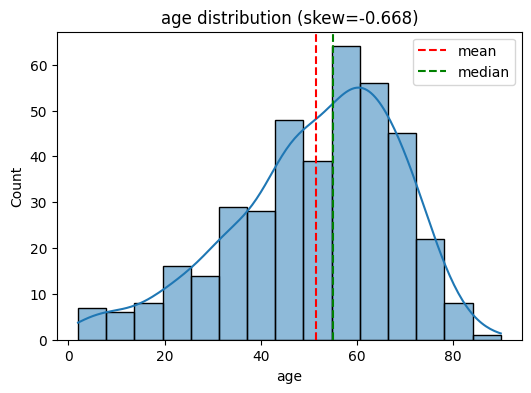

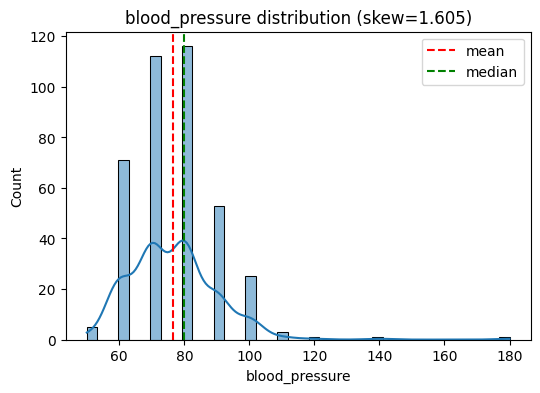

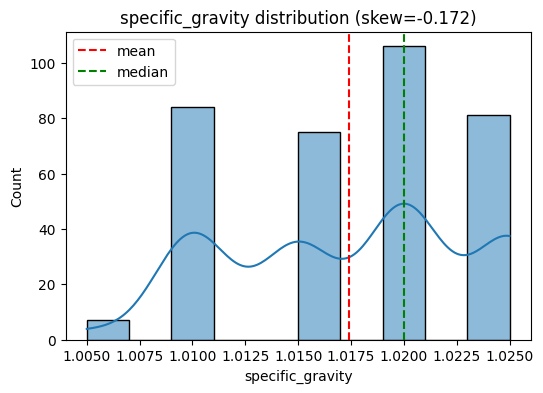

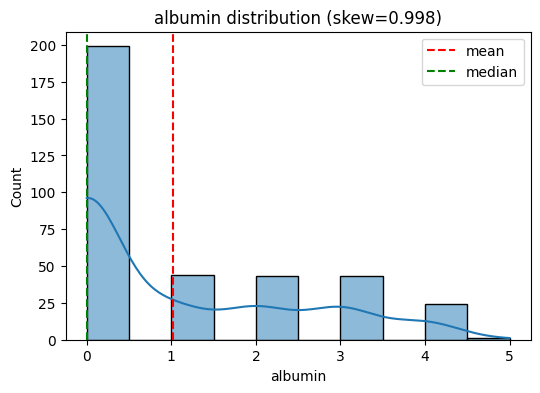

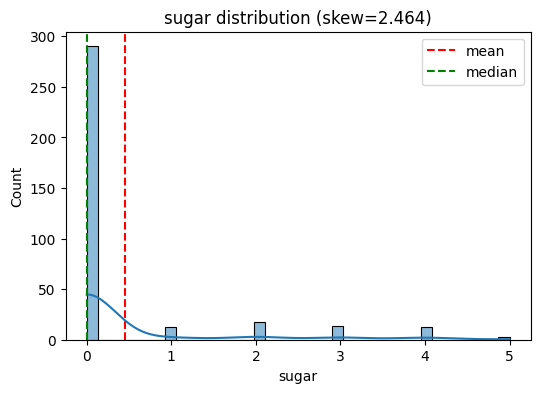

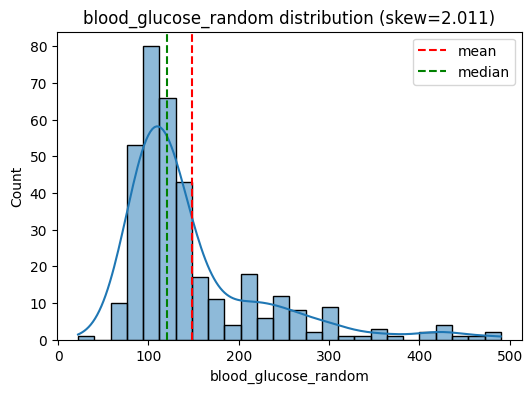

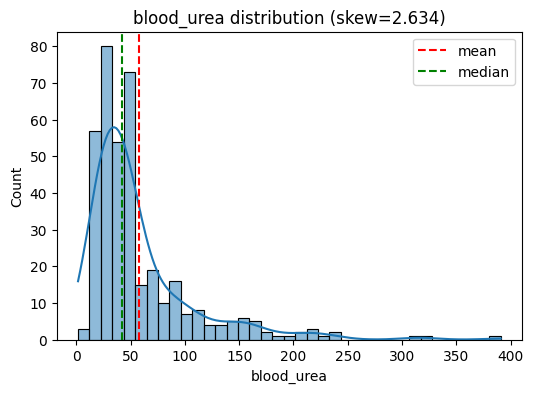

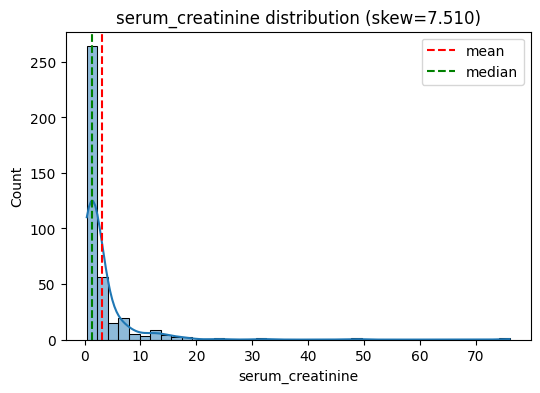

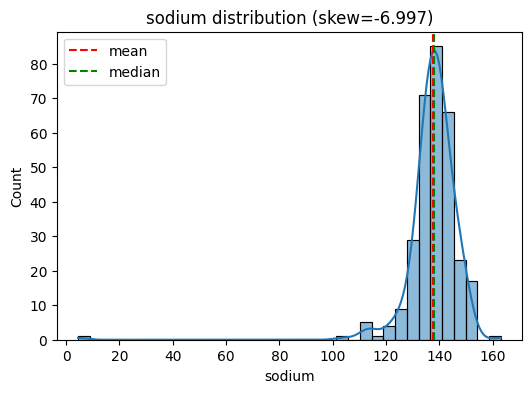

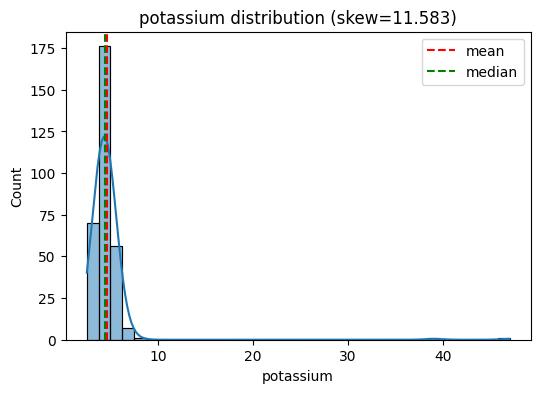

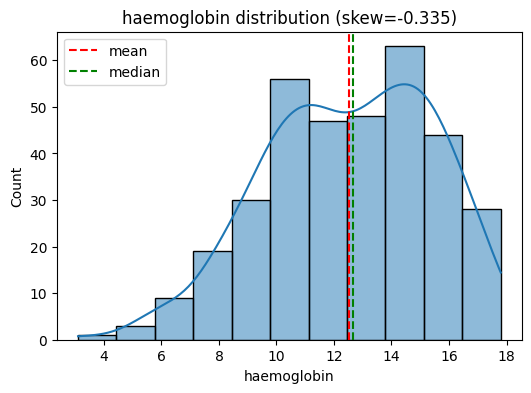

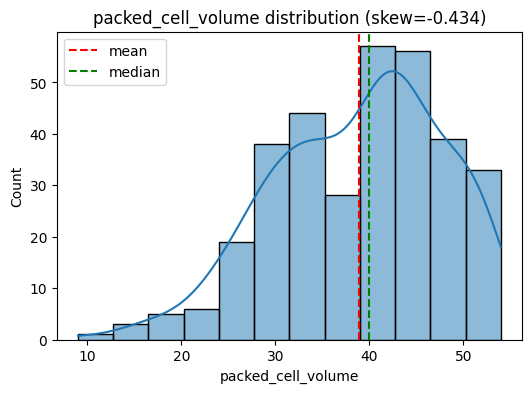

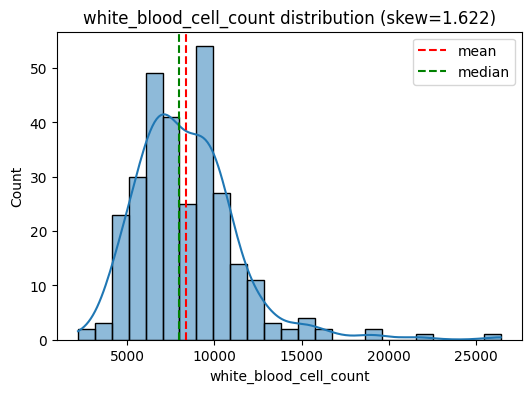

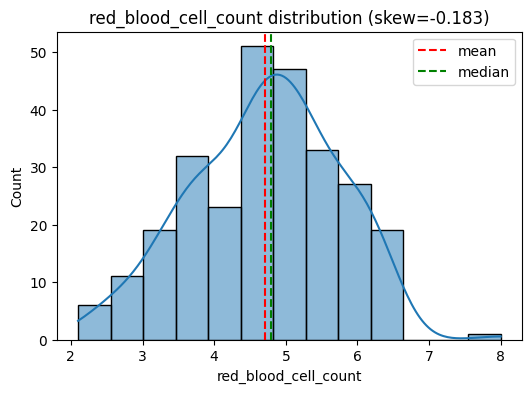

In [381]:
import seaborn as sns
import matplotlib.pyplot as plt

high_skew_col = []
low_skew_col = []

for col in numeric_col:
    skew_val = df[col].skew()

    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.axvline(df[col].mean(), color="red", linestyle="--", label="mean")
    plt.axvline(df[col].median(), color="green", linestyle="--", label="median")
    plt.title(f"{col} distribution (skew={skew_val:.3f})")
    plt.legend()
    plt.show()

    if abs(skew_val) < 0.7:
        low_skew_col.append(col)
    else:
        high_skew_col.append(col)


In [382]:
import pandas as pd

summary = pd.DataFrame({
    "Type": ["High skew", "Low skew"],
    "Columns": [", ".join(high_skew_col), ", ".join(low_skew_col)],
    "Count": [len(high_skew_col), len(low_skew_col)]
})

display(summary)


,Type,Columns,Count
0,High skew,"blood_pressure, albumin, sugar, blood_glucose_...",9
1,Low skew,"age, specific_gravity, haemoglobin, packed_cel...",5


WHY WE NEED SKEWNESS ? 
TO FILL OUT MISSING VALUES WE NEED TO KNOW THE SKEWNESS 
SO THAT WE CAN DECIDE WEATHER TO FILL WITH MEAN OR MEDIAN


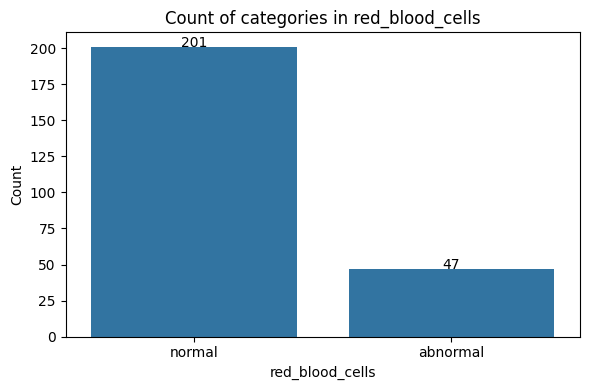

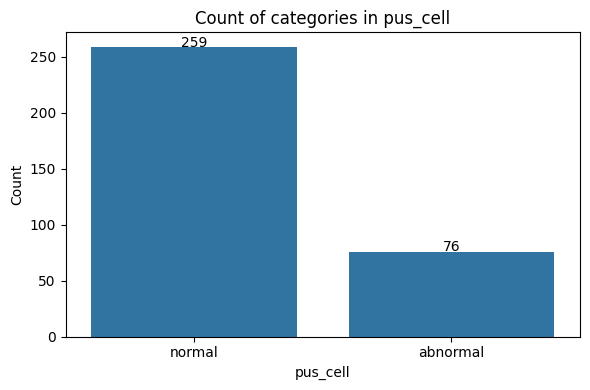

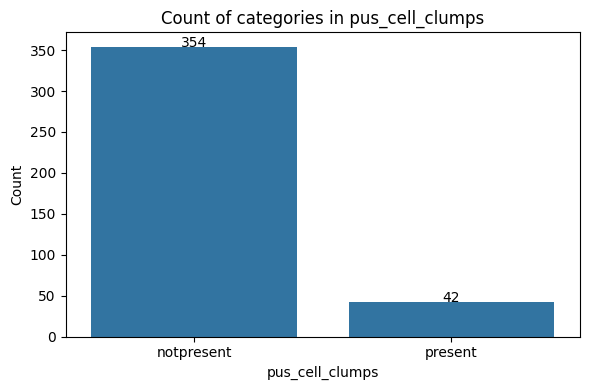

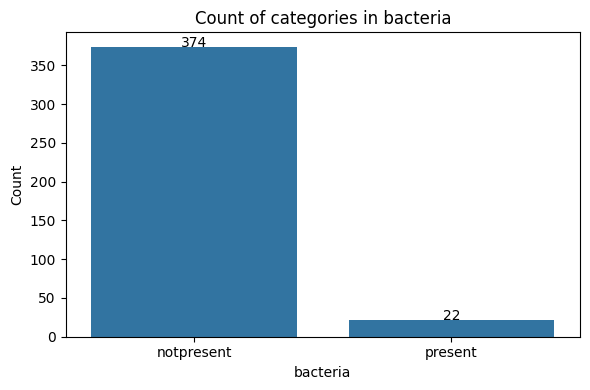

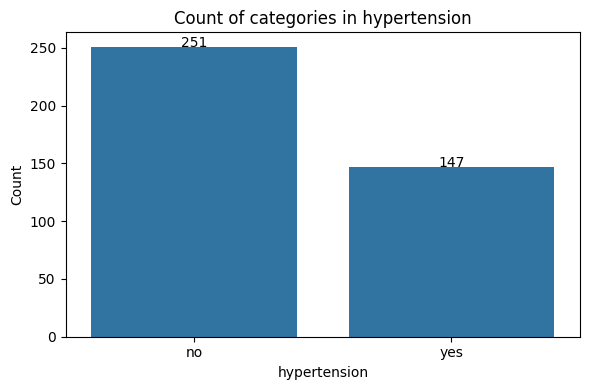

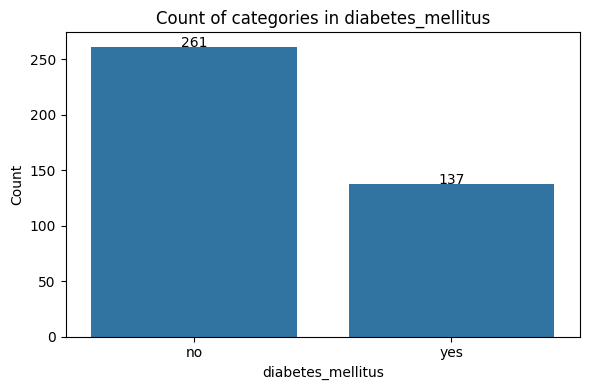

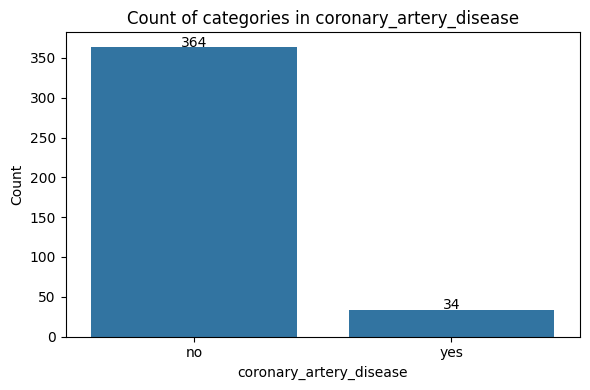

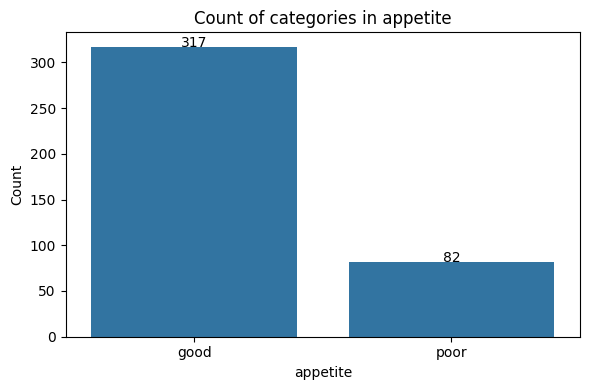

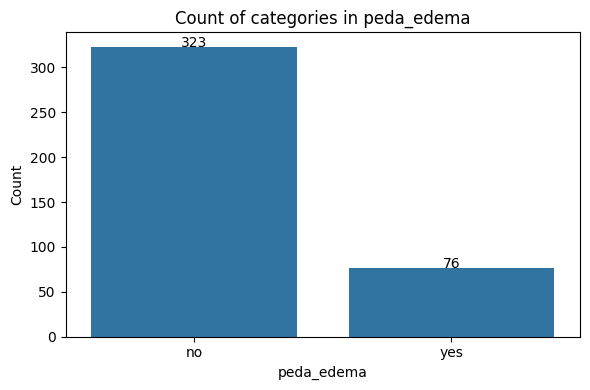

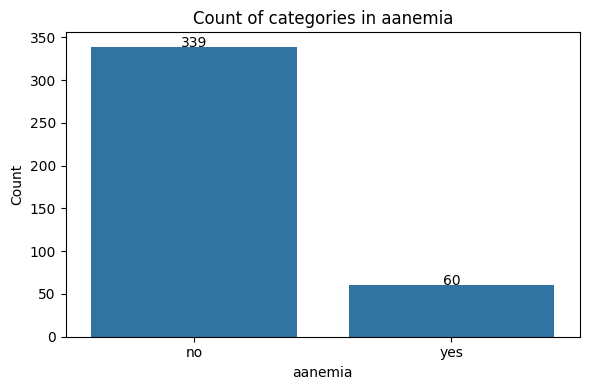

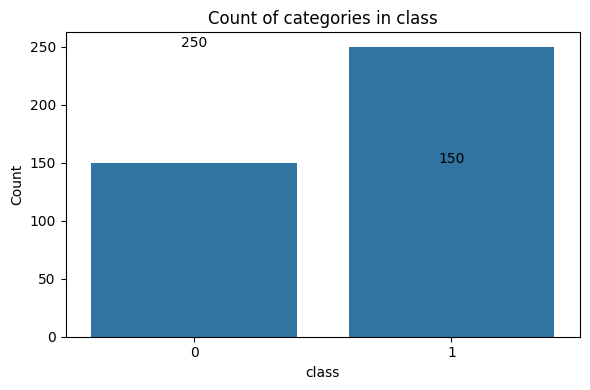

In [383]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in category_col:
    vc = df[col].value_counts(dropna=True)
    plt.figure(figsize=(6,4))
    sns.barplot(x=vc.index, y=vc.values)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Count of categories in {col}")

    for i, v in enumerate(vc.values):
        plt.text(i, v + 0.2, str(v), ha="center")

    plt.tight_layout()
    plt.show()


WE NEED THIS TO FIND IF THERE ARE ANY CLASS IMBALACNES

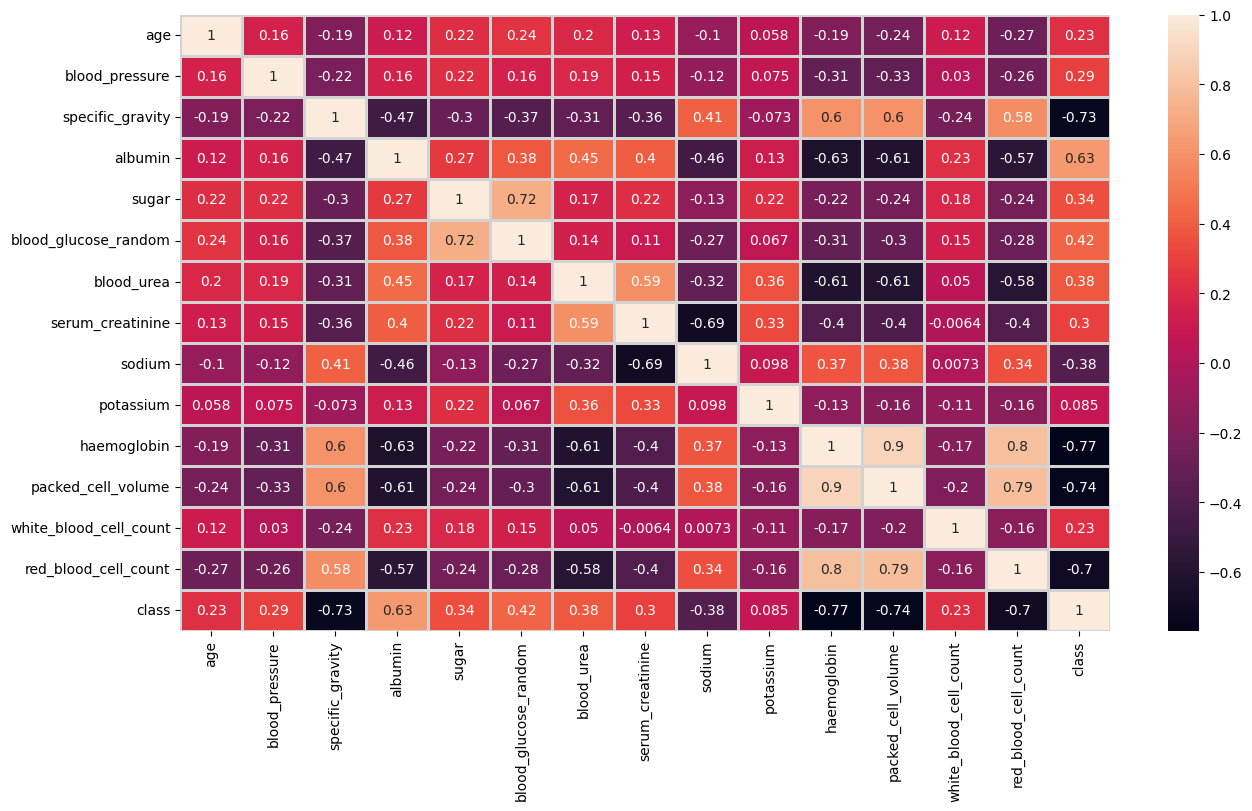

In [384]:
''' NOW CORRELATION'''

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (15, 8))
sns.heatmap(df.corr( numeric_only= True), annot = True, linewidths = 2, linecolor = 'lightgrey')
plt.show()

In [385]:
''' lets add class into numeric col and remove it from
categorical col because we typecasted it into integer '''

category_col . remove( "class" )
numeric_col . append ( "class")

print(numeric_col)
print(category_col)


['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium', 'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count', 'class']
['red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria', 'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema', 'aanemia']


In [386]:
''' checking if there are any missing values '''
print("missing values in both numerical and categorical data")
df.isna().sum().sort_values(ascending = False)

missing values in both numerical and categorical data


red_blood_cells            152
red_blood_cell_count       131
white_blood_cell_count     106
potassium                   88
sodium                      87
packed_cell_volume          71
pus_cell                    65
haemoglobin                 52
sugar                       49
specific_gravity            47
albumin                     46
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
blood_pressure              12
age                          9
pus_cell_clumps              4
bacteria                     4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
aanemia                      1
class                        0
dtype: int64

In [387]:
''' lets see the number of missing values in nuerical cols'''
print("missing values in numerical data")
df[numeric_col].isna().sum().sort_values(ascending = False)

missing values in numerical data


red_blood_cell_count      131
white_blood_cell_count    106
potassium                  88
sodium                     87
packed_cell_volume         71
haemoglobin                52
sugar                      49
specific_gravity           47
albumin                    46
blood_glucose_random       44
blood_urea                 19
serum_creatinine           17
blood_pressure             12
age                         9
class                       0
dtype: int64

In [388]:
print("missing values in categorical data")
df[category_col].isna().sum().sort_values(ascending = False)

missing values in categorical data


red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
aanemia                      1
dtype: int64

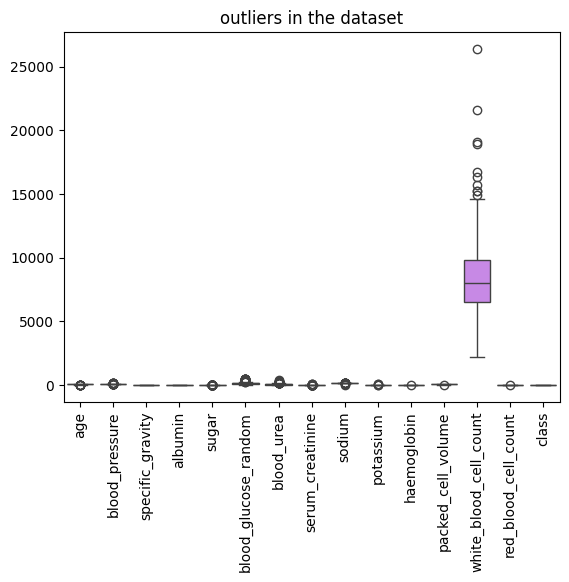

In [389]:
''' lets check if there are any outliers in the nuerical cols '''
''' why only numerical cols ?? 
ans : what the fk u mean by an outlier in category cols ?
we have only 2 unique values in category so there is no way 
where we can consider a value as an outlier in category cols
'''

import seaborn as sns

sns.boxplot(data=df[numeric_col])
plt.title("outliers in the dataset")
plt.xticks(rotation=90)
plt.show()


STEP 4 : TRAIN TEST SPLIT 

In [390]:
from sklearn.model_selection import train_test_split

x = df.drop("class", axis = 1)
y = df["class"]

x_train , x_test , y_train , y_test = train_test_split(
    x , y , 
    test_size = 0.2,
    shuffle = True , 
    random_state = 1 ,
    stratify = y
)

display(x_train.shape)
display(x_test.shape)

(320, 24)

(80, 24)

STEP 5 : PREPROCESSING 

'''FIRST LETS START WITH FILLING MISSING VALUES IN NUEMRICAL COLUMS'''
'''
    WE CAN EITHER FILL WITH MEAN OR MEDIAN 
'''
''' IF THE NUMBER OF OUTLIERS ARE HIGH OR THE ABS(SKEWNESS) IS ABOVE 0.7
    WE FILL IT WITH MEDIAN ELSE WE FILL IT WITH MEAN '''

In [391]:
''' nowl lets calcuate the number of outliers for numeric cols '''


import pandas as pd 
from IPython.display import Markdown , display

numeric_col_with_outliers = []

def get_iqr_bounds(train_df):
    numeric_col = train_df.select_dtypes(include = "number").columns
    bounds = {}
    for col in numeric_col :
        q1 = train_df[col].quantile(0.25)
        q3 = train_df[col].quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        bounds[col] = (low,high)
    return bounds

def outlier_count_with_bounds(df,bounds):
    rows = []
    for col, (low, high) in bounds.items():
        count = ((df[col] < low) | (df[col] > high)).sum()
        rows.append([col, count, low, high])
        if count >= 40 :
            numeric_col_with_outliers.append(col)
    return pd.DataFrame(rows, columns=["Feature", "Outlier_Count", "Lower_Bound", "Upper_Bound"])

iqr_bounds = get_iqr_bounds(x_train)

outliers = outlier_count_with_bounds(df, iqr_bounds)

display(Markdown("### Dataset Outliers"))
display(outliers)

''' we will consider going for outliers only when the outllier 
in the whole dataset is greater than 10% '''

### Dataset Outliers

,Feature,Outlier_Count,Lower_Bound,Upper_Bound
0,age,7,7.5000,99.5000
1,blood_pressure,36,55.0000,95.0000
2,specific_gravity,0,0.9950,1.0350
3,albumin,0,-3.0000,5.0000
4,sugar,61,0.0000,0.0000
5,blood_glucose_random,34,4.5000,256.5000
6,blood_urea,38,-29.5000,122.5000
7,serum_creatinine,53,-1.8375,5.4625
8,sodium,16,124.5000,152.5000
9,potassium,4,2.1500,6.5500


' we will consider going for outliers only when the outllier \nin the whole dataset is greater than 10% '

In [392]:
''' the cols with more than 10% outliers are'''
print(numeric_col_with_outliers)
print(high_skew_col)


['sugar', 'serum_creatinine']
['blood_pressure', 'albumin', 'sugar', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium', 'potassium', 'white_blood_cell_count']


In [393]:
'''
    THE RULE OF THUMB FOR FILLING OUT MISSING VALUES :
    --> IF NUMBER OF OUTLIERS > 10% == MEDIAN
    --> IF SKEWNESS IS >= 0.7  == MEDIAN
    --> ELSE == MEAN
'''
if "class" in numeric_col:
    numeric_col . remove ("class")
for col in numeric_col:
    if col == "class" or col not in x_train.columns:
        continue
    if col in numeric_col_with_outliers or col in high_skew_col:
        fill_value = x_train[col].median()
    else:
        fill_value = x_train[col].mean()

    x_train[col] = x_train[col].fillna(fill_value)
    x_test[col] = x_test[col].fillna(fill_value)

'''
    now lets check the number of missing values 
'''

print("after filling missing values, checking for missing value in train")
x_train[numeric_col].isna().sum().sort_values(ascending = False)



after filling missing values, checking for missing value in train


age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
haemoglobin               0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
dtype: int64

In [394]:
print("after filling missing values, checking for missing value in test")
x_test[numeric_col].isna().sum().sort_values(ascending = False)

after filling missing values, checking for missing value in test


age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
haemoglobin               0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
dtype: int64

In [395]:
''' now lets go with filling out missing values in categorical data '''

'''
    qus : how do u fill missing values in categorical data ??
    ans : generally u fill it with mean if missing values are less than 40%
          unless the feature is really important u reach out a domain expert

'''

for col in category_col:
    fill_value_cat = x_train[col].mode()[0]

    # fill both train and test with that value 
    x_train[col] = x_train[col].fillna(fill_value_cat)
    x_test[col] = x_test[col].fillna(fill_value_cat)

print("after filling missing values, checking for missing value in train")
x_train[category_col].isna().sum().sort_values(ascending = False)


after filling missing values, checking for missing value in train


red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
aanemia                    0
dtype: int64

In [396]:
print("after filling missing values, checking for missing value in test")
x_test[category_col].isna().sum().sort_values(ascending = False)

after filling missing values, checking for missing value in test


red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
aanemia                    0
dtype: int64

TILL HERE THE HANDLING MISSING VALUES IS DONE NOW NEXT IS HANDLING OUTLIERS IN NUMERICAL DATA ONLY NOT IN CATEGORICAL DATA , 
CATEGORIAL DATA DOESNOT HAVE ANYTHING LIKE CALLED AS OUTLIERS IN OUR DATASET 

In [397]:
''' we already displayed all the outliers of the dataset above now lets handle them'''

''' wait but how do we handle outliers ? 
drop the entire row ? 
drop the particular cell ?? crazy or what 
fill it with mean / median ??
cap it with mix and maximum value ??
'''

''' the answer is cap it with iqr bounds '''

for col , (low , high) in iqr_bounds.items():
    x_train[col] = x_train[col].clip(lower = low , upper = high)
    x_test[col] = x_test[col].clip(lower = low , upper = high)


# now lets check the number of outliers again
train_outliers_atfer_handling = outlier_count_with_bounds(x_train , iqr_bounds)
test_outliers_atfer_handling = outlier_count_with_bounds(x_test , iqr_bounds)

# now lets print them 
display(Markdown("### training dataset outliers after outliers handling "))
display(train_outliers_atfer_handling)

display(Markdown("### testing dataset outliers after outliers handling "))
display(test_outliers_atfer_handling)

### training dataset outliers after outliers handling 

,Feature,Outlier_Count,Lower_Bound,Upper_Bound
0,age,0,7.5000,99.5000
1,blood_pressure,0,55.0000,95.0000
2,specific_gravity,0,0.9950,1.0350
3,albumin,0,-3.0000,5.0000
4,sugar,0,0.0000,0.0000
5,blood_glucose_random,0,4.5000,256.5000
6,blood_urea,0,-29.5000,122.5000
7,serum_creatinine,0,-1.8375,5.4625
8,sodium,0,124.5000,152.5000
9,potassium,0,2.1500,6.5500


### testing dataset outliers after outliers handling 

,Feature,Outlier_Count,Lower_Bound,Upper_Bound
0,age,0,7.5000,99.5000
1,blood_pressure,0,55.0000,95.0000
2,specific_gravity,0,0.9950,1.0350
3,albumin,0,-3.0000,5.0000
4,sugar,0,0.0000,0.0000
5,blood_glucose_random,0,4.5000,256.5000
6,blood_urea,0,-29.5000,122.5000
7,serum_creatinine,0,-1.8375,5.4625
8,sodium,0,124.5000,152.5000
9,potassium,0,2.1500,6.5500


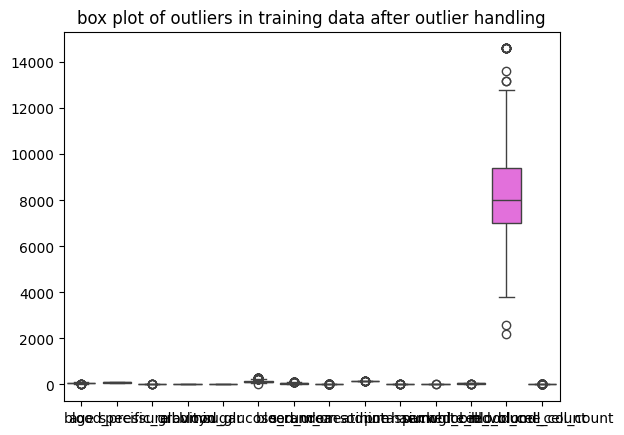

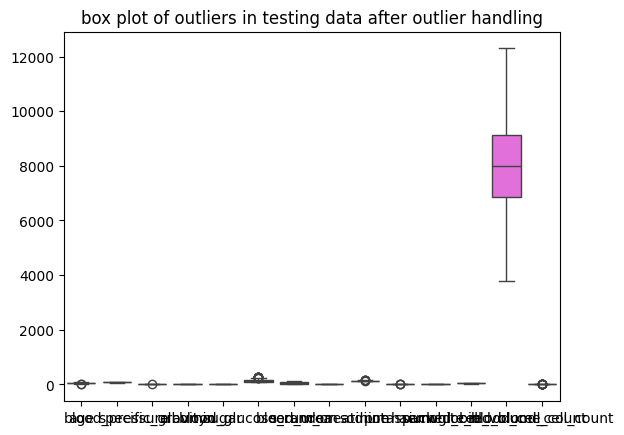

' you can see that the outliers are still there becasue after clipping\nwhen u calucuate box plot new q1 and q3 are being calcualted so new bounds \n'

In [398]:
''' lets see if any outliers exists by using box plot '''

import seaborn as sns


sns.boxplot(data = x_train)
plt.title("box plot of outliers in training data after outlier handling")
plt.show()

sns.boxplot(data = x_test)
plt.title("box plot of outliers in testing data after outlier handling")
plt.show()

''' you can see that the outliers are still there becasue after clipping
when u calucuate box plot new q1 and q3 are being calcualted so new bounds 
'''

OUTLIER HANDLING IS ALSO DONE NOW ENDCODING FOR CATEGORICAL FEATURES

In [399]:
''' since the number if unique values are are only 2 
we can go ahead with label encoder '''
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in category_col:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col].astype(str))  # fit only on train
    x_test[col]  = le.transform(x_test[col].astype(str))       # transform only
    encoders[col] = le



In [400]:
display(x_train)
display(x_test)

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia
117,51.544872,70.0,1.020000,0.0,0.0,1,1,0,0,219.0,36.0,1.3000,139.0,3.7,12.5,37.000000,9800.0,4.400000,0,0,0,0,0,0
320,57.000000,60.0,1.020000,0.0,0.0,1,1,0,0,105.0,49.0,1.2000,150.0,4.7,15.7,44.000000,10400.0,6.200000,0,0,0,0,0,0
203,51.544872,90.0,1.017455,0.0,0.0,1,1,0,0,207.0,80.0,5.4625,142.0,5.5,8.5,38.844106,8000.0,4.729767,1,1,0,0,0,1
284,33.000000,80.0,1.025000,0.0,0.0,1,1,0,0,100.0,37.0,1.2000,142.0,4.0,16.9,52.000000,6700.0,6.000000,0,0,0,0,0,0
130,50.000000,90.0,1.010000,2.0,0.0,1,0,1,1,128.0,122.5,5.4625,134.0,4.8,8.2,22.000000,14600.0,2.700000,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,15.000000,60.0,1.020000,3.0,0.0,1,1,0,0,86.0,15.0,0.6000,138.0,4.0,11.0,33.000000,7700.0,3.800000,1,1,0,0,0,0
398,17.000000,60.0,1.025000,0.0,0.0,1,1,0,0,114.0,50.0,1.0000,135.0,4.9,14.2,51.000000,7200.0,5.900000,0,0,0,0,0,0
6,68.000000,70.0,1.010000,0.0,0.0,1,1,0,0,100.0,54.0,5.4625,124.5,4.0,12.4,36.000000,8000.0,4.729767,0,0,0,0,0,0
139,41.000000,70.0,1.015000,2.0,0.0,1,0,0,1,121.0,68.0,2.8000,132.0,4.1,11.1,33.000000,8000.0,4.729767,1,0,0,0,1,1


,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia
251,23.0,80.0,1.025000,0.0,0.0,1,1,0,0,70.0,36.0,1.0000,150.0,4.6,17.000000,52.000000,9800.0,5.000000,0,0,0,0,0,0
311,56.0,60.0,1.025000,0.0,0.0,1,1,0,0,132.0,18.0,1.1000,147.0,4.7,13.700000,45.000000,7500.0,5.600000,0,0,0,0,0,0
307,47.0,60.0,1.020000,0.0,0.0,1,1,0,0,137.0,17.0,0.5000,150.0,3.5,13.600000,44.000000,7900.0,4.500000,0,0,0,0,0,0
287,39.0,70.0,1.025000,0.0,0.0,1,1,0,0,124.0,22.0,0.6000,137.0,3.8,13.400000,43.000000,8000.0,4.729767,0,0,0,0,0,0
300,45.0,60.0,1.020000,0.0,0.0,1,1,0,0,114.0,26.0,0.7000,141.0,4.2,15.000000,43.000000,9200.0,5.800000,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,65.0,80.0,1.015000,2.0,0.0,1,1,1,0,215.0,122.5,2.5000,138.0,4.3,13.200000,41.000000,8000.0,4.729767,0,1,0,0,0,0
56,76.0,70.0,1.015000,3.0,0.0,1,0,1,0,121.0,122.5,5.4625,131.0,4.4,10.200000,30.000000,11300.0,3.400000,1,1,1,1,1,0
21,60.0,90.0,1.017455,0.0,0.0,1,1,0,0,121.0,122.5,5.4625,124.5,4.3,10.900000,32.000000,6200.0,3.600000,1,1,1,0,0,0
211,54.0,95.0,1.015000,0.0,0.0,1,1,0,0,103.0,18.0,1.2000,138.0,4.3,12.466071,38.844106,8000.0,4.729767,0,0,0,0,0,0


In [401]:
''' 
    always check with info to make sure u filled all missing values 
    and encoded all categorical data 
'''
'''
    dont do info for df because u will end up with the missing values 
    and not encoded features because we are never making changes on df
    we are changing on x_train and x_test
'''

x_train.info()
x_test.info()

<class 'pandas.DataFrame'>
Index: 320 entries, 117 to 155
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      320 non-null    float64
 1   blood_pressure           320 non-null    float64
 2   specific_gravity         320 non-null    float64
 3   albumin                  320 non-null    float64
 4   sugar                    320 non-null    float64
 5   red_blood_cells          320 non-null    int64  
 6   pus_cell                 320 non-null    int64  
 7   pus_cell_clumps          320 non-null    int64  
 8   bacteria                 320 non-null    int64  
 9   blood_glucose_random     320 non-null    float64
 10  blood_urea               320 non-null    float64
 11  serum_creatinine         320 non-null    float64
 12  sodium                   320 non-null    float64
 13  potassium                320 non-null    float64
 14  haemoglobin              320 non-null   

In [402]:
x_test.info()

<class 'pandas.DataFrame'>
Index: 80 entries, 251 to 53
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      80 non-null     float64
 1   blood_pressure           80 non-null     float64
 2   specific_gravity         80 non-null     float64
 3   albumin                  80 non-null     float64
 4   sugar                    80 non-null     float64
 5   red_blood_cells          80 non-null     int64  
 6   pus_cell                 80 non-null     int64  
 7   pus_cell_clumps          80 non-null     int64  
 8   bacteria                 80 non-null     int64  
 9   blood_glucose_random     80 non-null     float64
 10  blood_urea               80 non-null     float64
 11  serum_creatinine         80 non-null     float64
 12  sodium                   80 non-null     float64
 13  potassium                80 non-null     float64
 14  haemoglobin              80 non-null     f

NOW THE LAST STEP REMANS STANDARDIZATION LETS GO WITH STANDARD SCALER FOR NOW 

In [403]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) split FIRST (before scaling)
x_tr_bms, x_val_bms, y_tr_bms, y_val_bms = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=1,
    stratify=y_train,
    shuffle=True
)

display(x_tr_bms.shape)
display(x_val_bms.shape)

# 2) scale AFTER split
scaler = StandardScaler()

x_tr_bms_scaled = scaler.fit_transform(x_tr_bms)   # fit only on train fold
x_val_bms_scaled = scaler.transform(x_val_bms)     # transform val
x_test_scaled = scaler.transform(x_test)           # transform test

x_tr_bms = pd.DataFrame(x_tr_bms_scaled, columns=x_tr_bms.columns, index=x_tr_bms.index)
x_val_bms = pd.DataFrame(x_val_bms_scaled, columns=x_val_bms.columns, index=x_val_bms.index)
x_test = pd.DataFrame(x_test_scaled, columns=x_test.columns, index=x_test.index)

display(Markdown("### train fold after scaling"))
display(x_tr_bms.head(10))

display(Markdown("### validation fold after scaling"))
display(x_val_bms.head(10))

display(Markdown("### test set after scaling"))
display(x_test.head(10))


(256, 24)

(64, 24)

### train fold after scaling

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia
239,-1.034958,1.304172,-0.442748,0.832190,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.630693,0.003737,-0.284238,-0.140840,-0.350180,-0.185395,0.039216,-0.140643,0.013535,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
378,1.151600,-1.381094,1.442817,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.326039,-0.260151,-0.721405,0.385512,0.692217,0.998616,0.398360,-0.271728,0.918302,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
151,1.447080,1.304172,0.020196,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,0.587921,-0.128207,-0.221785,0.560963,1.734614,-1.010614,-1.038217,-0.140643,0.013535,1.238811,1.405967,-0.306622,-0.510964,-0.510964,2.195036
163,-0.325804,0.409083,-1.385530,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,0.372871,-0.326123,-0.034428,0.385512,-0.350180,-1.225889,-1.397361,-0.096948,-1.783433,1.238811,-0.711254,-0.306622,1.957087,-0.510964,2.195036
335,0.501542,-1.381094,0.500035,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.093069,-0.161193,-0.971215,0.210061,0.692217,0.639825,1.116648,1.039122,1.035769,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
369,1.387984,-0.486005,0.500035,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.576930,-0.062235,-0.783857,1.087315,-1.243663,0.424550,0.877219,0.864342,0.096035,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
259,-0.975862,0.409083,0.500035,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.630693,-0.622997,-0.534048,-0.491742,0.990044,1.321528,0.757504,-1.757359,0.565902,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
73,0.001876,1.751716,-0.442748,0.832190,0.0,-2.645751,-2.136637,-0.350438,-0.240523,-0.182673,1.883936,2.127988,-1.018094,0.096561,-2.732811,-2.953653,-0.883459,0.013535,1.238811,-0.711254,-0.306622,-0.510964,1.957087,2.195036
271,-1.271343,0.409083,1.442817,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.774059,-0.820912,-0.971215,1.087315,0.692217,0.496308,0.398360,0.296307,-0.256365,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
138,1.269792,0.409083,-1.385530,0.082047,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.791980,0.036723,-0.284238,0.736413,-1.243663,0.017707,0.020553,-0.140643,0.013535,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573


### validation fold after scaling

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia
295,-0.443997,-0.486005,0.020196,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.594851,-0.820912,-0.721405,2.140019,-1.094749,0.926858,1.356078,0.558477,2.092969,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
308,-0.503093,0.409083,1.442817,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-1.042871,-0.128207,-0.908762,-0.491742,0.841131,0.532188,1.116648,-0.621289,0.213502,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
17,-0.266708,0.409083,0.020196,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.451485,1.224217,1.964050,0.210061,-0.945836,-0.113636,0.020553,-0.140643,0.013535,1.238811,-0.711254,-0.306622,1.957087,-0.510964,-0.455573
353,-0.739477,-1.381094,0.500035,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.953267,-0.425081,-0.908762,2.140019,0.990044,0.424550,1.475793,-1.101934,-0.256365,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
399,0.383350,0.409083,1.442817,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.146831,-1.051814,-0.596500,0.560963,-1.243663,1.213891,1.715222,-0.664984,1.623102,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
12,0.974311,-0.486005,-0.442748,1.582333,0.0,0.377964,0.468025,2.853569,-0.240523,1.233069,0.729428,0.028024,0.034610,2.181355,-0.974735,-1.277647,1.694547,-1.548499,1.238811,1.405967,3.261344,1.957087,1.957087,-0.455573
132,-0.089420,0.409083,0.020196,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,1.430198,2.395219,2.127988,-0.316291,0.245475,-1.369405,-1.756506,2.131498,-2.370766,1.238811,-0.711254,-0.306622,-0.510964,1.957087,2.195036
133,1.092503,1.751716,-0.442748,2.332476,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.379802,2.395219,2.026503,-0.316291,0.841131,-0.149515,-0.200214,0.034137,3.561303,1.238811,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
289,-0.562189,-0.486005,0.500035,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.827821,-0.590011,-0.721405,0.911864,0.543303,1.500923,0.518075,-0.533898,0.683369,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
20,0.560638,0.409083,-0.442748,0.832190,0.0,-2.645751,-2.136637,-0.350438,-0.240523,0.605841,2.395219,1.152168,-0.491742,1.287872,-1.692317,-1.756506,0.383697,-1.783433,1.238811,1.405967,3.261344,1.957087,1.957087,2.195036


### test set after scaling

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia
251,-1.685016,0.409083,1.442817,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-1.239999,-0.458067,-0.658953,2.140019,0.394389,1.644440,1.595507,0.645867,0.330968,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
311,0.265157,-1.381094,1.442817,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.128911,-1.051814,-0.596500,1.613667,0.543303,0.460429,0.757504,-0.359118,1.035769,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
307,-0.266708,-1.381094,0.500035,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.039307,-1.084800,-0.971215,2.140019,-1.243663,0.424550,0.637789,-0.184338,-0.256365,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
287,-0.739477,-0.486005,1.442817,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.272277,-0.919870,-0.908762,-0.140840,-0.796922,0.352792,0.518075,-0.140643,0.013535,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
300,-0.384900,-1.381094,0.500035,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.451485,-0.787926,-0.846310,0.560963,-0.201266,0.926858,0.518075,0.383697,1.270702,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
212,-0.680381,-0.486005,-0.442748,1.582333,0.0,0.377964,0.468025,-0.350438,-0.240523,2.039504,2.395219,2.127988,-1.018094,1.883527,-0.544186,-0.918502,0.208917,-1.548499,1.238811,1.405967,-0.306622,1.957087,1.957087,-0.455573
144,0.501542,1.304172,-1.385530,0.832190,0.0,-2.645751,0.468025,-0.350438,-0.240523,-0.612772,0.102695,0.152929,-0.316291,1.287872,-0.472427,-0.679073,0.951732,-0.726232,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573
183,-1.271343,-0.486005,-0.442748,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.684455,1.850950,2.127988,-0.491742,-0.052353,0.017707,0.020553,-0.140643,0.013535,-0.807225,-0.711254,-0.306622,1.957087,-0.510964,-0.455573
142,1.210696,1.304172,0.020196,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.989108,2.395219,2.127988,-0.491742,1.436786,0.017707,0.020553,-0.140643,0.013535,-0.807225,1.405967,-0.306622,-0.510964,-0.510964,-0.455573
338,0.619734,0.409083,0.500035,-0.668096,0.0,0.377964,0.468025,-0.350438,-0.240523,-0.128911,-0.524039,-0.783857,1.613667,-1.243663,1.931473,0.637789,-1.582579,-0.256365,-0.807225,-0.711254,-0.306622,-0.510964,-0.510964,-0.455573


THE ENTIRE PREPROCESSING IS DONE , DONT ASK FOR FEATURE ENGG I AM NOT A DOMAIN EXPERT , WE CAN PROCEED WITH BASLINE MODEL SELECTION AND AFTER SELECTING THE BEST MODEL(S) WE CAN GO AHEAD TO MAKE K FOLD FOR THE BEST HP 

STEP 5 : BASELINE MODEL SELECTION 

In [404]:
''' baseline_model_1 : logistic regression '''

''' since we know this is a classification model 
we can always try it out with logistic regression 
if this was a regression model then we will go with linear 
regression '''

'''
    i understand that there are over 20 features so using 
    logistic regression may be bad , i mean it may be way too simple 
    but what is the harm in trying it out 
'''

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , precision_score , recall_score , confusion_matrix , classification_report , f1_score , roc_auc_score

'''model traning : train with x_tr_bms and y_tr_bms '''

lr = LogisticRegression (
    max_iter = 1000 ,
    random_state = 1
)

lr.fit(x_tr_bms , y_tr_bms)

''' till here model training is done '''
''' now lets validate '''

y_val_prob_lr = lr.predict_proba(x_val_bms)[:,1]
threshold = 0.5
y_val_pred_lr = (y_val_prob_lr >= threshold).astype(int)


''' metrcis '''

print("Logistic regression")
print("Accuracy :", round(accuracy_score(y_val_bms, y_val_pred_lr), 4))
print("Precision:", round(precision_score(y_val_bms, y_val_pred_lr), 4))
print("Recall   :", round(recall_score(y_val_bms, y_val_pred_lr), 4))
print("F1-score :", round(f1_score(y_val_bms, y_val_pred_lr), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val_bms, y_val_prob_lr), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_bms, y_val_pred_lr))

print("\nClassification Report:")
print(classification_report(y_val_bms, y_val_pred_lr))



Logistic regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
ROC-AUC  : 1.0

Confusion Matrix:
[[24  0]
 [ 0 40]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        40

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64



In [ ]:
''' baseline_model_2 : desicion tree'''

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_auc_score
from sklearn.metrics import confusion_matrix , classification_report

'''model training'''

dt = DecisionTreeClassifier(
    random_state = 69 
)
dt.fit(x_tr_bms , y_tr_bms)

'''prediction'''

y_val_pred_dt = dt.predict(x_val_bms)
y_val_prob_dt = dt.predict_proba(x_val_bms)[:, 1]

'''metrics '''

print("decisionTreeClassifier")
print("Accuracy :", round(accuracy_score(y_val_bms, y_val_pred_dt), 4))
print("Precision :", round(precision_score(y_val_bms, y_val_pred_dt), 4))
print("Recall   :", round(recall_score(y_val_bms, y_val_pred_dt), 4))
print("F1-score :", round(f1_score(y_val_bms, y_val_pred_dt), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val_bms, y_val_prob_dt), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_bms, y_val_pred_dt))

print("\nClassification Report:")
print(classification_report(y_val_bms, y_val_pred_dt))


decisionTreeClassifier
Accuracy : 0.9219
Precision : 0.9487
Recall   : 0.925
F1-score : 0.9367
ROC-AUC  : 0.9208

Confusion Matrix:
[[22  2]
 [ 3 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        24
           1       0.95      0.93      0.94        40

    accuracy                           0.92        64
   macro avg       0.91      0.92      0.92        64
weighted avg       0.92      0.92      0.92        64



In [ ]:
'''final testing '''

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report, f1_score, roc_auc_score
)

# final train on full train folds (train-fold + val-fold)
x_train_final = pd.concat([x_tr_bms, x_val_bms], axis=0)
y_train_final = pd.concat([y_tr_bms, y_val_bms], axis=0)

lr = LogisticRegression(max_iter=2000, random_state=1)
lr.fit(x_train_final, y_train_final)

# final test on holdout test set
y_test_prob = lr.predict_proba(x_test)[:, 1]
threshold = 0.5
y_test_pred = (y_test_prob >= threshold).astype(int)

print("Logistic regression")
print("Accuracy :", round(accuracy_score(y_test, y_test_pred), 4))
print("Precision:", round(precision_score(y_test, y_test_pred), 4))
print("Recall   :", round(recall_score(y_test, y_test_pred), 4))
print("F1-score :", round(f1_score(y_test, y_test_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_test_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Logistic regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
ROC-AUC  : 1.0

Confusion Matrix:
[[30  0]
 [ 0 50]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

